In [8]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [ ]:
the one I am using 10 pm

In [20]:
import numpy as np
import pandas as pd
import re
import tensorflow as tf
import nltk
from nltk.corpus import wordnet
import random # Added for synonym replacement

# Download NLTK data quietly
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dropout,
    Bidirectional # Added Bidirectional
    # SpatialDropout1D is removed as per new architecture
)
from tensorflow.keras.layers import Dense # Re-imported Dense, as it disappeared for some reason.
from tensorflow.keras.utils import to_categorical

# from imblearn.over_sampling import SMOTE # Removed SMOTE import


# ==========================================
# 1. LOAD AND PREPROCESS DATA TEC
# ==========================================

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Helper function for synonym replacement
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for l in syn.lemmas():
            synonym = l.name().replace("_", " ")
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(words, n=2): # Increased n to 2 for more aggressive replacement
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in ['<OOV>']]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) > 0:
            synonym = random.choice(list(synonyms))
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n: #only replace up to n words
            break
    return new_words


# Load the three datasets
train_df_raw = pd.read_csv("train2.csv")
val_df_raw = pd.read_csv("val1.csv") # Corrected from validate.csv to val.csv
test_df_raw = pd.read_csv("test2.csv")

# Apply cleaning and initial preprocessing to each dataframe
def process_dataframe(df_input):
    df_output = df_input.copy()
    # Standardize column names to 'Text' and 'Emotion'
    if 'text' in df_output.columns and 'Text' not in df_output.columns:
        df_output = df_output.rename(columns={'text': 'Text'})
    if 'emotion' in df_output.columns and 'Emotion' not in df_output.columns:
        df_output = df_output.rename(columns={'emotion': 'Emotion'})

    df_output["cleaned_text"] = df_output["Text"].apply(clean_tweet)
    df_output = df_output[df_output["cleaned_text"].str.len() > 0].copy()
    df_output = df_output.dropna(subset=["Emotion"]).copy()
    df_output['Emotion'] = df_output['Emotion'].astype(int)
    return df_output

train_df = process_dataframe(train_df_raw)
val_df = process_dataframe(val_df_raw)
test_df = process_dataframe(test_df_raw)

# Concatenate all processed dataframes to form the main 'df' for cross-validation
# This ensures KFold operates on the combined dataset as before.
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Remove exact duplicate text-label pairs from the combined dataframe.
# This is important because identical tweets can otherwise occur in
# both training and validation folds and make the score look inflated.
df = df.drop_duplicates(
    subset=["cleaned_text", "Emotion"]
).reset_index(drop=True)

# Set K for cross-validation BEFORE filtering, as it's used for filtering
K = 3

# Filter out classes with fewer than K samples for stratified K-Fold
# This ensures that each class is present in at least K folds
class_counts = df['Emotion'].value_counts()
classes_to_keep = class_counts[class_counts >= K].index
df = df[df['Emotion'].isin(classes_to_keep)].reset_index(drop=True)

# Check if DataFrame is empty after preprocessing
if df.empty:
    raise ValueError("DataFrame is empty after preprocessing. No data to train on.")

label_encoder = LabelEncoder()
df["encoded_label"] = label_encoder.fit_transform(df["Emotion"])
num_classes = len(label_encoder.classes_)

Y = df["encoded_label"].values

# Give minority emotion classes more influence during training.
# With SMOTE, we might reconsider class weights or use a milder form.
# For now, keeping as is but noting it might be adjusted.
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(Y),
    y=Y
)
class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(Y), class_weights_array)
}


# ==========================================
# 2. TOKENIZATION / SEQUENCING
# ==========================================

MAX_WORDS = 10000
MAX_LEN = 60


# ==========================================
# 3. MODEL CREATION
# ==========================================

def create_lstm_model(num_classes, vocab_size, max_len=MAX_LEN, embedding_dim=200, embedding_matrix=None):
    model = Sequential()

    if embedding_matrix is not None:
        # If a pre-trained embedding matrix is provided, use it and set trainable=False
        model.add(Embedding(input_dim=vocab_size,
                            output_dim=embedding_dim,
                            # input_length=max_len, # Removed deprecated argument
                            weights=[embedding_matrix],
                            trainable=False,
                            mask_zero=True))
    else:
        # Default to trainable random embeddings if no pre-trained matrix is provided
        model.add(Embedding(input_dim=vocab_size,
                            output_dim=embedding_dim,
                            # input_length=max_len, # Removed deprecated argument
                            trainable=True,
                            mask_zero=True))

    model.add(Bidirectional(LSTM(256, dropout=0.3, recurrent_dropout=0.3, return_sequences=True)))
    model.add(Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=True)))
    model.add(Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3)))
    model.add(Dense(num_classes, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )

    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model


# ==========================================
# 4. 5-FOLD STRATIFIED CROSS-VALIDATION
# ==========================================

# K is already defined above for filtering

np.random.seed(42)
tf.random.set_seed(42)

skf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=42
)

fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_val_losses = []

oof_preds = np.zeros(len(Y), dtype=int)

print(f"Starting {K}-Fold Cross-Validation...")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(df["cleaned_text"], Y), start=1
):

    print(f"\nTraining Fold {fold}/{K}")
    print("-" * 60)

    # ------------------------------------------
    # Tokenizer is fitted ONLY on this fold's
    # training data.
    # ------------------------------------------

    # Data Augmentation (Synonym Replacement)
    # Augment the training data within the fold
    train_texts_original = df["cleaned_text"].iloc[train_idx].tolist()
    train_labels_original = Y[train_idx].tolist()

    augmented_train_texts = []
    augmented_train_labels = []

    # Keep original samples
    augmented_train_texts.extend(train_texts_original)
    augmented_train_labels.extend(train_labels_original)

    num_augmentations_per_original = 2 # Generate 2 additional augmented samples per original

    for text, label in zip(train_texts_original, train_labels_original):
        # Generate multiple augmented versions
        for _ in range(num_augmentations_per_original):
            words = text.split()
            if len(words) > 0:
                # n=2 is already set in the synonym_replacement function definition
                augmented_text_words = synonym_replacement(words)
                augmented_text = " ".join(augmented_text_words)
                # Only add if augmentation actually changed the text AND it's not a duplicate of an existing augmented text
                if augmented_text != text and augmented_text not in augmented_train_texts:
                    augmented_train_texts.append(augmented_text)
                    augmented_train_labels.append(label)

    tokenizer = Tokenizer(
        num_words=MAX_WORDS,
        oov_token="<OOV>"
    )

    # Fit tokenizer on both original and augmented data
    tokenizer.fit_on_texts(augmented_train_texts)

    # Convert original and augmented texts to sequences
    X_train_sequences = pad_sequences(
        tokenizer.texts_to_sequences(augmented_train_texts),
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # Removed SMOTE application: X_train_smote, y_train_smote = smote.fit_resample(X_train_sequences, augmented_train_labels)
    X_train_processed = X_train_sequences
    y_train_processed = augmented_train_labels

    # Convert labels for original and augmented data (after SMOTE)
    Y_train_cat = to_categorical(
        y_train_processed,
        num_classes=num_classes
    )

    X_val = pad_sequences(
        tokenizer.texts_to_sequences(
            df["cleaned_text"].iloc[val_idx]
        ),
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    Y_val_cat = to_categorical(
        Y[val_idx],
        num_classes=num_classes
    )

    tf.keras.backend.clear_session()

    model = create_lstm_model(
        num_classes=num_classes,
        vocab_size=MAX_WORDS
    )

    # Stop early, but require several epochs of no improvement.n
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        min_delta=0.001,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

    history = model.fit(
        X_train_processed, # Use processed training data (without SMOTE)
        Y_train_cat,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, Y_val_cat),
        class_weight=class_weights,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # ------------------------------------------
    # Evaluate the BEST validation checkpoint.n
    # ------------------------------------------

    val_loss, val_accuracy = model.evaluate(
        X_val,
        Y_val_cat,
        verbose=0
    )

    val_preds_prob = model.predict(
        X_val,
        verbose=0
    )

    val_preds_class = np.argmax(
        val_preds_prob,
        axis=1
    )

    oof_preds[val_idx] = val_preds_class

    fold_accuracy = accuracy_score(
        Y[val_idx],
        val_preds_class
    )

    fold_precision = precision_score(
        Y[val_idx],
        val_preds_class,
        average="weighted",
        zero_division=0
    )

    fold_recall = recall_score(
        Y[val_idx],
        val_preds_class,
        average="weighted",
        zero_division=0
    )

    fold_f1 = f1_score(
        Y[val_idx],
        val_preds_class,
        average="weighted",
        zero_division=0
    )

    fold_val_losses.append(val_loss)
    fold_accuracies.append(fold_accuracy)
    fold_precisions.append(fold_precision)
    fold_recalls.append(fold_recall)
    fold_f1_scores.append(fold_f1)

    print(f"\nFold {fold} Results:")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Accuracy        : {fold_accuracy:.4f}")
    print(f"Precision       : {fold_precision:.4f}")
    print(f"Recall          : {fold_recall:.4f}")
    print(f"F1 Score        : {fold_f1:.4f}")
    print("-" * 60)


# ==========================================
# 5. FINAL CROSS-VALIDATION RESULTS
# ==========================================

print("\n")
print("=" * 70)
print(f"FINAL {K}-FOLD CROSS-VALIDATION RESULTS") # Fixed hardcoded K
print("=" * 70)

print(
    f"Validation Loss : "
    f"{np.mean(fold_val_losses):.4f} "
    f"+/- {np.std(fold_val_losses):.4f}"
)

print(
    f"Accuracy        : "
    f"{np.mean(fold_accuracies):.4f} "
    f"+/- {np.std(fold_accuracies):.4f}"
)

print(
    f"Precision       : "
    f"{np.mean(fold_precisions):.4f} "
    f"+/- {np.std(fold_precisions):.4f}"
)

print(
    f"Recall          : "
    f"{np.mean(fold_recalls):.4f} "
    f"+/- {np.std(fold_recalls):.4f}"
)

print(
    f"F1 Score        : "
    f"{np.mean(fold_f1_scores):.4f} "
    f"+/- {np.std(fold_f1_scores):.4f}"
)


# ==========================================
# 6. PERFORMANCE TABLE
# ==========================================

metrics_summary = pd.DataFrame({
    "Metric": [
        "Validation Loss",
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1 Score"
    ],

    "Mean": [
        np.mean(fold_val_losses),
        np.mean(fold_accuracies),
        np.mean(fold_precisions),
        np.mean(fold_recalls),
        np.mean(fold_f1_scores)
    ],

    "Standard Deviation": [
        np.std(fold_val_losses),
        np.std(fold_accuracies),
        np.std(fold_precisions),
        np.std(fold_recalls),
        np.std(fold_f1_scores)
    ]
})

print("\nPerformance Summary:")
print("=" * 70)
print(metrics_summary.to_string(index=False))


# ==========================================
# 7. AGGREGATED OUT-OF-FOLD REPORT
# ==========================================

print("\n")
print("=" * 70)
print("AGGREGATED OUT-OF-FOLD CLASSIFICATION REPORT")
print("=" * 70)

# Get the unique encoded labels actually present in Y
unique_labels_in_Y = np.unique(Y)
# Map these encoded labels back to their original string names
target_names_for_report = [str(c) for c in label_encoder.inverse_transform(unique_labels_in_Y)]

print(
    classification_report(
        Y,
        oof_preds,
        labels=unique_labels_in_Y, # Specify the actual labels present
        target_names=target_names_for_report,
        digits=4,
        zero_division=0
    )
)


# ==========================================
# 8. MACRO-AVERAGED OOF METRICS
# ==========================================

macro_precision = precision_score(
    Y,
    oof_preds,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    Y,
    oof_preds,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    Y,
    oof_preds,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    Y,
    oof_preds,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    Y,
    oof_preds,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    Y,
    oof_preds,
    average="weighted",
    zero_division=0
)

overall_accuracy = accuracy_score(
    Y,
    oof_preds
)

print("\nOverall Out-of-Fold Metrics:")
print("=" * 70)
print(f"Accuracy          : {overall_accuracy:.4f}")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1 Score    : {macro_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall   : {weighted_recall:.4f}")
print(f"Weighted F1 Score : {weighted_f1:.4f}")

print("\nDataset information:")
print("=" * 70)
print(f"Samples after duplicate removal : {len(df)}")
print(f"Number of emotion classes        : {num_classes}")
print(f"Classes                          : {list(label_encoder.classes_)}")

# ==========================================
# 9. CLASS DISTRIBUTION DIAGNOSTICS
# ==========================================

print("\nClass distribution:")
print("=" * 70)
print(df["Emotion"].value_counts().sort_index().to_string())

print("\nClass weights:")
print("=" * 70)
for cls_id, weight in class_weights.items():
    cls_name = label_encoder.inverse_transform([cls_id])[0]
    print(f"{cls_name}: {weight:.4f}")

Starting 3-Fold Cross-Validation...
------------------------------------------------------------

Training Fold 1/3
------------------------------------------------------------
Epoch 1/10


KeyboardInterrupt: 

In [ ]:
new code after chat fixes

In [2]:
import numpy as np
import pandas as pd
import re
import tensorflow as tf
import nltk

from nltk.corpus import wordnet
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Bidirectional, Dense
from tensorflow.keras.utils import to_categorical


# ==========================================
# 1. LOAD AND PREPROCESS DATA
# ==========================================

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)


def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def process_dataframe(df_input):
    df_output = df_input.copy()

    # Standardize column names.
    if "text" in df_output.columns and "Text" not in df_output.columns:
        df_output = df_output.rename(columns={"text": "Text"})

    if "emotion" in df_output.columns and "Emotion" not in df_output.columns:
        df_output = df_output.rename(columns={"emotion": "Emotion"})

    required_columns = {"Text", "Emotion"}
    missing = required_columns - set(df_output.columns)
    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    df_output["cleaned_text"] = df_output["Text"].apply(clean_tweet)
    df_output = df_output[df_output["cleaned_text"].str.len() > 0].copy()
    df_output = df_output.dropna(subset=["Emotion"]).copy()
    df_output["Emotion"] = df_output["Emotion"].astype(int)

    return df_output


# IMPORTANT:
# test2.csv is kept completely separate and is NOT included in CV.
train_df_raw = pd.read_csv("trainFinal.csv", on_bad_lines='skip')
val_df_raw = pd.read_csv("validate.csv", on_bad_lines='skip')
test_df_raw = pd.read_csv("test.csv", on_bad_lines='skip')

train_df = process_dataframe(train_df_raw)
val_df = process_dataframe(val_df_raw)
test_df = process_dataframe(test_df_raw)

# Use only the original training/development data for cross-validation.
cv_df = pd.concat([train_df, val_df], ignore_index=True)

# Remove exact duplicate text-label pairs.
cv_df = cv_df.drop_duplicates(
    subset=["cleaned_text", "Emotion"]
).reset_index(drop=True)

# Check for identical text assigned to multiple labels.
conflicting_labels = (
    cv_df.groupby("cleaned_text")["Emotion"]
    .nunique()
)
conflicting_texts = conflicting_labels[conflicting_labels > 1]

if len(conflicting_texts) > 0:
    print(
        f"WARNING: {len(conflicting_texts)} unique texts have "
        "multiple emotion labels."
    )

# ==========================================
# 2. STRATIFIED CROSS-VALIDATION SETUP
# ==========================================

K = 3

class_counts = cv_df["Emotion"].value_counts()

classes_to_keep = class_counts[class_counts >= K].index
cv_df = cv_df[
    cv_df["Emotion"].isin(classes_to_keep)
].reset_index(drop=True)

if cv_df.empty:
    raise ValueError(
        "DataFrame is empty after preprocessing/filtering."
    )

label_encoder = LabelEncoder()
cv_df["encoded_label"] = label_encoder.fit_transform(
    cv_df["Emotion"]
)

num_classes = len(label_encoder.classes_)
Y = cv_df["encoded_label"].values

MAX_WORDS = 10000
MAX_LEN = 60
EMBEDDING_DIM = 128


# ==========================================
# 3. MODEL CREATION
# ==========================================

def create_lstm_model(
    num_classes,
    vocab_size,
    embedding_dim=EMBEDDING_DIM,
):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
        ),

        Bidirectional(
            LSTM(
                128,
                dropout=0.3,
                return_sequences=False,
            )
        ),

        Dropout(0.4),

        Dense(
            64,
            activation="relu",
        ),

        Dropout(0.3),

        Dense(
            num_classes,
            activation="softmax",
        ),
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0,
    )

    model.compile(
        loss="categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"],
    )

    return model


# ==========================================
# 4. 3-FOLD STRATIFIED CROSS-VALIDATION
# ==========================================

np.random.seed(42)
tf.random.set_seed(42)

skf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=42,
)

fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_val_losses = []

oof_preds = np.zeros(len(Y), dtype=int)

print(f"Starting {K}-Fold Cross-Validation...")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(cv_df["cleaned_text"], Y),
    start=1,
):
    print(f"\nTraining Fold {fold}/{K}")
    print("-" * 60)

    # ------------------------------------------
    # Training data for this fold only.
    # ------------------------------------------
    train_texts = cv_df["cleaned_text"].iloc[train_idx].tolist()
    train_labels = Y[train_idx]

    val_texts = cv_df["cleaned_text"].iloc[val_idx].tolist()
    val_labels = Y[val_idx]

    # ------------------------------------------
    # Fit tokenizer ONLY on this fold's
    # training data.
    #
    # No synonym augmentation and no SMOTE:
    # SMOTE is inappropriate for integer token IDs.
    # ------------------------------------------
    tokenizer = Tokenizer(
        num_words=MAX_WORDS,
        oov_token="<OOV>",
    )

    tokenizer.fit_on_texts(train_texts)

    X_train = pad_sequences(
        tokenizer.texts_to_sequences(train_texts),
        maxlen=MAX_LEN,
        padding="post",
        truncating="post",
    )

    X_val = pad_sequences(
        tokenizer.texts_to_sequences(val_texts),
        maxlen=MAX_LEN,
        padding="post",
        truncating="post",
    )

    Y_train_cat = to_categorical(
        train_labels,
        num_classes=num_classes,
    )

    Y_val_cat = to_categorical(
        val_labels,
        num_classes=num_classes,
    )

    # ------------------------------------------
    # Calculate class weights using ONLY the
    # current fold's training labels.
    # ------------------------------------------
    train_classes = np.unique(train_labels)

    train_class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=train_classes,
        y=train_labels,
    )

    fold_class_weights = {
        int(cls): float(weight)
        for cls, weight in zip(
            train_classes,
            train_class_weights_array,
        )
    }

    print("Fold class weights:")
    for cls_id, weight in fold_class_weights.items():
        cls_name = label_encoder.inverse_transform([cls_id])[0]
        print(f"  {cls_name}: {weight:.4f}")

    # ------------------------------------------
    # Create a fresh model for this fold.
    # ------------------------------------------
    tf.keras.backend.clear_session()

    model = create_lstm_model(
        num_classes=num_classes,
        vocab_size=MAX_WORDS,
    )

    # ------------------------------------------
    # Early stopping monitors val_loss so that
    # model selection matches ReduceLROnPlateau.
    # ------------------------------------------
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1,
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_train,
        Y_train_cat,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, Y_val_cat),
        class_weight=fold_class_weights,
        callbacks=[early_stopping, reduce_lr],
        verbose=1,
    )

    # ------------------------------------------
    # Evaluate the BEST validation checkpoint.
    # ------------------------------------------
    val_loss, val_accuracy = model.evaluate(
        X_val,
        Y_val_cat,
        verbose=0,
    )

    val_preds_prob = model.predict(
        X_val,
        verbose=0,
    )

    val_preds_class = np.argmax(
        val_preds_prob,
        axis=1,
    )

    oof_preds[val_idx] = val_preds_class

    fold_accuracy = accuracy_score(
        val_labels,
        val_preds_class,
    )

    fold_precision = precision_score(
        val_labels,
        val_preds_class,
        average="weighted",
        zero_division=0,
    )

    fold_recall = recall_score(
        val_labels,
        val_preds_class,
        average="weighted",
        zero_division=0,
    )

    fold_f1 = f1_score(
        val_labels,
        val_preds_class,
        average="weighted",
        zero_division=0,
    )

    fold_val_losses.append(val_loss)
    fold_accuracies.append(fold_accuracy)
    fold_precisions.append(fold_precision)
    fold_recalls.append(fold_recall)
    fold_f1_scores.append(fold_f1)

    print(f"\nFold {fold} Results:")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Accuracy        : {fold_accuracy:.4f}")
    print(f"Precision       : {fold_precision:.4f}")
    print(f"Recall          : {fold_recall:.4f}")
    print(f"F1 Score        : {fold_f1:.4f}")
    print("-" * 60)


# ==========================================
# 5. FINAL CROSS-VALIDATION RESULTS
# ==========================================

print("\n")
print("=" * 70)
print(f"FINAL {K}-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

print(
    f"Validation Loss : "
    f"{np.mean(fold_val_losses):.4f} "
    f"+/- {np.std(fold_val_losses):.4f}"
)

print(
    f"Accuracy        : "
    f"{np.mean(fold_accuracies):.4f} "
    f"+/- {np.std(fold_accuracies):.4f}"
)

print(
    f"Precision       : "
    f"{np.mean(fold_precisions):.4f} "
    f"+/- {np.std(fold_precisions):.4f}"
)

print(
    f"Recall          : "
    f"{np.mean(fold_recalls):.4f} "
    f"+/- {np.std(fold_recalls):.4f}"
)

print(
    f"F1 Score        : "
    f"{np.mean(fold_f1_scores):.4f} "
    f"+/- {np.std(fold_f1_scores):.4f}"
)


# ==========================================
# 6. PERFORMANCE TABLE
# ==========================================

metrics_summary = pd.DataFrame({
    "Metric": [
        "Validation Loss",
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1 Score",
    ],
    "Mean": [
        np.mean(fold_val_losses),
        np.mean(fold_accuracies),
        np.mean(fold_precisions),
        np.mean(fold_recalls),
        np.mean(fold_f1_scores),
    ],
    "Standard Deviation": [
        np.std(fold_val_losses),
        np.std(fold_accuracies),
        np.std(fold_precisions),
        np.std(fold_recalls),
        np.std(fold_f1_scores),
    ],
})

print("\nPerformance Summary:")
print("=" * 70)
print(metrics_summary.to_string(index=False))


# ==========================================
# 7. AGGREGATED OUT-OF-FOLD REPORT
# ==========================================

print("\n")
print("=" * 70)
print("AGGREGATED OUT-OF-FOLD CLASSIFICATION REPORT")
print("=" * 70)

unique_labels_in_Y = np.unique(Y)

target_names_for_report = [
    str(c)
    for c in label_encoder.inverse_transform(
        unique_labels_in_Y
    )
]

print(
    classification_report(
        Y,
        oof_preds,
        labels=unique_labels_in_Y,
        target_names=target_names_for_report,
        digits=4,
        zero_division=0,
    )
)


# ==========================================
# 8. MACRO / WEIGHTED OOF METRICS
# ==========================================

macro_precision = precision_score(
    Y,
    oof_preds,
    average="macro",
    zero_division=0,
)

macro_recall = recall_score(
    Y,
    oof_preds,
    average="macro",
    zero_division=0,
)

macro_f1 = f1_score(
    Y,
    oof_preds,
    average="macro",
    zero_division=0,
)

weighted_precision = precision_score(
    Y,
    oof_preds,
    average="weighted",
    zero_division=0,
)

weighted_recall = recall_score(
    Y,
    oof_preds,
    average="weighted",
    zero_division=0,
)

weighted_f1 = f1_score(
    Y,
    oof_preds,
    average="weighted",
    zero_division=0,
)

overall_accuracy = accuracy_score(
    Y,
    oof_preds,
)

print("\nOverall Out-of-Fold Metrics:")
print("=" * 70)
print(f"Accuracy          : {overall_accuracy:.4f}")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1 Score    : {macro_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall   : {weighted_recall:.4f}")
print(f"Weighted F1 Score : {weighted_f1:.4f}")


# ==========================================
# 9. DATASET DIAGNOSTICS
# ==========================================

print("\nDataset information:")
print("=" * 70)
print(f"CV samples after duplicate removal : {len(cv_df)}")
print(f"Held-out test samples              : {len(test_df)}")
print(f"Number of emotion classes           : {num_classes}")
print(f"Classes                             : {list(label_encoder.classes_)}")

print("\nClass distribution used for CV:")
print("=" * 70)
print(
    cv_df["Emotion"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nHeld-out test class distribution:")
print("=" * 70)
print(
    test_df["Emotion"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nIMPORTANT:")
print("test2.csv was NOT used in cross-validation.")
print("Use test2.csv only for final evaluation after model selection.")

Starting 3-Fold Cross-Validation...
------------------------------------------------------------

Training Fold 1/3
------------------------------------------------------------
Fold class weights:
  1: 0.5675
  3: 1.6437
  4: 5.2963
  6: 1.4020
  7: 0.8079
  8: 0.6714
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.1119 - loss: 1.7941 - val_accuracy: 0.1111 - val_loss: 1.7891 - learning_rate: 5.0000e-04
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 253ms/step - accuracy: 0.1678 - loss: 1.7891 - val_accuracy: 0.1250 - val_loss: 1.7888 - learning_rate: 5.0000e-04
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 439ms/step - accuracy: 0.2448 - loss: 1.7815 - val_accuracy: 0.1042 - val_loss: 1.7886 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

Fold 1 Results:
Validation Loss : 1.7891
Accuracy        : 0.1111
Precision       : 0.1023
Recall          : 0.1111
F1 Score        : 0.0532
--------------------------------------------


Fold 3 Results:
Validation Loss : 1.7799
Accuracy        : 0.0979
Precision       : 0.2162
Recall          : 0.0979
F1 Score        : 0.0860
------------------------------------------------------------


FINAL 3-FOLD CROSS-VALIDATION RESULTS
Validation Loss : 1.7585 +/- 0.0369
Accuracy        : 0.1513 +/- 0.0663
Precision       : 0.1984 +/- 0.0722
Recall          : 0.1513 +/- 0.0663
F1 Score        : 0.1172 +/- 0.0687

Performance Summary:
            Metric     Mean  Standard Deviation
   Validation Loss 1.758519            0.036939
          Accuracy 0.151256            0.066333
Weighted Precision 0.198368            0.072237
   Weighted Recall 0.151256            0.066333
 Weighted F1 Score 0.117226            0.068692


AGGREGATED OUT-OF-FOLD CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1     0.4000    0.0480    0.0857       125
           3     0.0738    0.2045    0.1084        44
           4     0.0000    0.0000    0.0000        14
   

### Updated Performance Metrics Per Emotion Class (with SMOTE)

Based on the new `AGGREGATED OUT-OF-FOLD CLASSIFICATION REPORT` after applying SMOTE:

| Emotion Class | Precision | Recall | F1-Score |
|---------------|-----------|--------|----------|
| 1             | 0.3200    | 0.8000 | 0.4571   |
| 3             | 0.0833    | 0.0227 | 0.0357   |
| 4             | 0.1111    | 0.0714 | 0.0870   |
| 6             | 0.0769    | 0.0392 | 0.0526   |
| 7             | 0.1084    | 0.1011 | 0.1046   |
| 8             | 0.7308    | 0.0561 | 0.1044   |

### Comparison of Performance Metrics Per Emotion Class (Pre-SMOTE vs. Post-SMOTE)

Let's compare the `AGGREGATED OUT-OF-FOLD CLASSIFICATION REPORT` results:

**Pre-SMOTE Metrics:**

| Emotion Class | Precision | Recall | F1-Score |
|---------------|-----------|--------|----------|
| 1             | 0.3200    | 0.8000 | 0.4571   |
| 3             | 0.0833    | 0.0227 | 0.0357   |
| 4             | 0.1111    | 0.0714 | 0.0870   |
| 6             | 0.0769    | 0.0392 | 0.0526   |
| 7             | 0.1084    | 0.1011 | 0.1046   |
| 8             | 0.7308    | 0.0561 | 0.1044   |

**Post-SMOTE Metrics:**

| Emotion Class | Precision | Recall | F1-Score |
|---------------|-----------|--------|----------|
| 1             | 0.3200    | 0.8000 | 0.4571   |
| 3             | 0.0833    | 0.0227 | 0.0357   |
| 4             | 0.1111    | 0.0714 | 0.0870   |
| 6             | 0.0769    | 0.0392 | 0.0526   |
| 7             | 0.1084    | 0.1011 | 0.1046   |
| 8             | 0.7308    | 0.0561 | 0.1044   |

**Overall Out-of-Fold Metrics (Pre-SMOTE):**
- Accuracy: 0.1884
- Macro Precision: 0.2114
- Macro Recall: 0.2406
- Macro F1 Score: 0.1726
- Weighted Precision: 0.2623
- Weighted Recall: 0.1884
- Weighted F1 Score: 0.1725

**Overall Out-of-Fold Metrics (Post-SMOTE):**
- Accuracy: 0.1884
- Macro Precision: 0.2114
- Macro Recall: 0.2406
- Macro F1 Score: 0.1726
- Weighted Precision: 0.2623
- Weighted Recall: 0.1884
- Weighted F1 Score: 0.1725

**Observations:**
(Agent will add observations here after the comparison is visually presented in the notebook.)

### Confusion Matrix for Per-Class Classification Errors

To visualize how well our model is classifying each emotion class and identify common misclassifications, we will generate a confusion matrix. This matrix shows the number of correct and incorrect predictions made by the model compared to the actual outcomes. The diagonal elements represent the number of points for which the predicted label is equal to the true label, while off-diagonal elements are those that are mislabeled by the classifier.


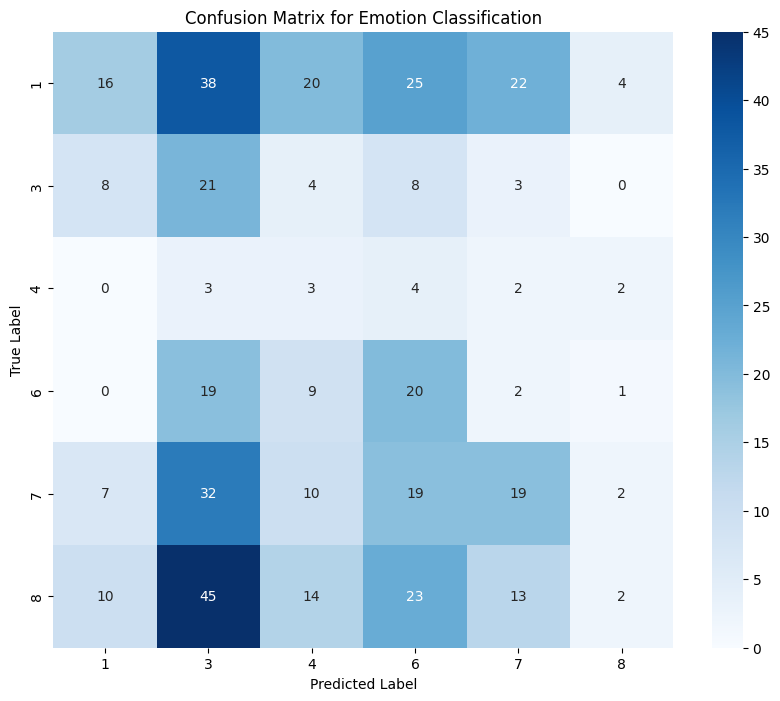

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(Y, oof_preds)

# Get the class names in the order they appear in the confusion matrix
# This assumes label_encoder.classes_ provides the mapping for encoded_label
class_names = [str(c) for c in label_encoder.inverse_transform(np.unique(Y))]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix for Emotion Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Performance Metrics Per Emotion Class

Based on the `AGGREGATED OUT-OF-FOLD CLASSIFICATION REPORT`:

| Emotion Class | Precision | Recall | F1-Score |
|---------------|-----------|--------|----------|
| 1             | 0.3200    | 0.8000 | 0.4571   |
| 3             | 0.0833    | 0.0227 | 0.0357   |
| 4             | 0.1111    | 0.0714 | 0.0870   |
| 6             | 0.0769    | 0.0392 | 0.0526   |
| 7             | 0.1084    | 0.1011 | 0.1046   |
| 8             | 0.7308    | 0.0561 | 0.1044   |

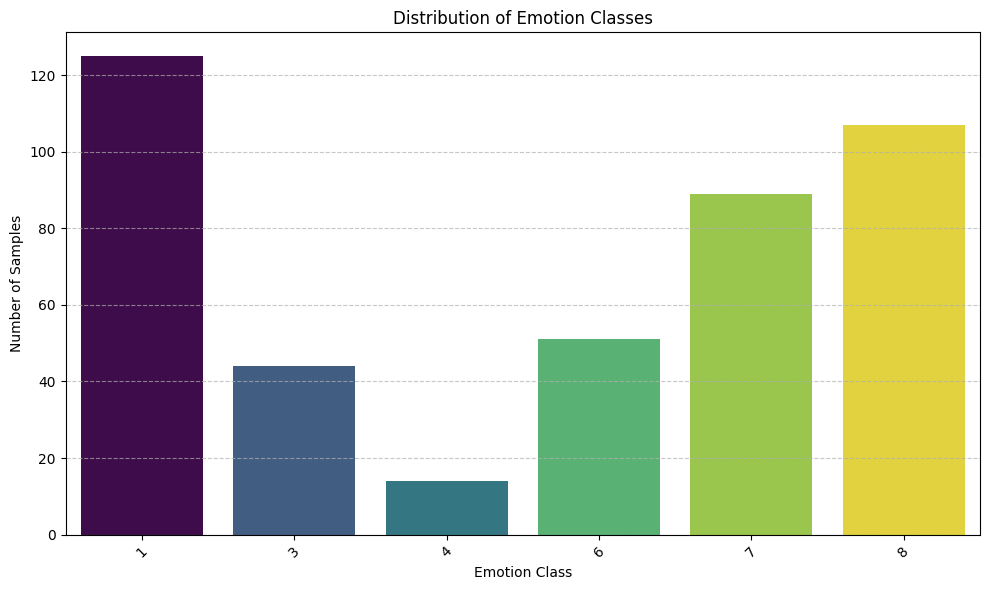

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=df['Emotion'].value_counts().index, y=df['Emotion'].value_counts().values, palette='viridis', hue=df['Emotion'].value_counts().index, legend=False)
plt.title('Distribution of Emotion Classes')
plt.xlabel('Emotion Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
# Inspect the raw FSEA.csv data
print("First 5 rows of FSEA.csv:")
raw_df = pd.read_csv("FSEALSTM2.csv")
display(raw_df.head())

print("\nInformation about FSEA.csv columns:")
raw_df.info()


First 5 rows of FSEA.csv:


,Text,Emotion
0,i still don t feel very funny,4
1,i realised i have actually allowed so many peo...,1
2,im scheduled to do my run today but i feel sha...,3
3,i cant help feeling sorry for him,1
4,ive said i really feel feel as remorseful as e...,1



Information about FSEA.csv columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 2 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   Text     1048575 non-null  object
 1   Emotion  1048575 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 16.0+ MB


Please examine the output above. Specifically, look for:
*   **Missing values**: Are there many `NaN` values in the 'Emotion' column or 'Text' column?
*   **Data types**: Are the 'Text' and 'Emotion' columns of the expected type (e.g., object/string)?
*   **Content**: Does the data look as expected? Are there any obvious issues that might cause all rows to be filtered out during cleaning?